In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use("ggplot")

# Data Transformations

Now that our dataset is complete, we still need to make sure it actually matches the assumptions our models rely on. Statistical models often work best when the following conditions are met:

* The predictors are not multicollinear.

* The predictors are not skewed too much. Extreme values distort the model parameters.

* The error term follows a normal distribution with a constant variance.

* There are no scale differences between predictors.

* The relationship between each predictor $x_i$ and the response variable $y$ is linear.

* The response is nothing but the sum of each effect (additive model).

These assumptions are rarely met in practice. Fortunately, we can use several data transformation techniques to address these violations. Some of these techniques also make the results more interpretable.

## Centering

Consider this bivariate regression equation:

$y = b_0 + b_1x_1$

Whenever $x_1 = 0$, we interpret the response variable as $y = b_0$. However, this may not always be the case. For example, if we have a regression equation explaining the impact of temperature on reaction output, and the reaction starts at a minimum of $T = 20°C$, we cannot make this interpretation directly. But if we center $x_1$, we can say that at the average reaction temperature, the reaction output is $b_0$.

Also, centering is used when creating interaction variables to decrease collinearity. We will come back to this topic in the "Interaction" section.


**Example 1**

$n = 1000$

$t \sim \mathcal{N}(25,\ 2^2)$

$\varepsilon \sim \mathcal{N}(0, 1)$

$y = 2t + 5 + \varepsilon$


In [2]:
np.random.seed(42)

n = 1000
e = np.random.normal(loc = 0, scale = 1, size = n)
t = np.random.normal(loc = 25, scale = 2, size = n) 
b0 = 5
y = 2 * t + b0 + e
X = sm.add_constant(t)
model = sm.OLS(y, X)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                 1.627e+04
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:00:27   Log-Likelihood:                -1396.6
No. Observations:                1000   AIC:                             2797.
Df Residuals:                     998   BIC:                             2807.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5179      0.392     14.092      0.0

The model caught the pattern successfully. However, we cannot say

"The reaction output is 5 when the temperature is at $0°C$"

for a reaction that starts at $T = 20°C$.

Let's build a centered model for the same problem:

In [3]:
#more interpretable
t_centered = t - np.mean(t)
X_centered = sm.add_constant(t_centered)

model_centered = sm.OLS(y, X_centered)
result_centered = model_centered.fit()

print(result_centered.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                 1.627e+04
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:00:27   Log-Likelihood:                -1396.6
No. Observations:                1000   AIC:                             2797.
Df Residuals:                     998   BIC:                             2807.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         55.3027      0.031   1786.508      0.0

This one is more interpretable. We can say that:

"At the average temperature, the reaction output is 55."

## Standardization


Consider this regression equation:


$y = b_0 + b_1x_1 + b_2x_2$


The corresponding OLS loss function will be


$L(X,y) = \sum_{i=1}^{n}(y_i - b_0 - b_1x_{i,1} - b_2x_{i,2})^2$


When there is a scale difference between $x_1$ and $x_2$, the coefficients are not comparable since each one is expressed in its own predictor's scale. For example, when there is a scale difference, a coefficient of 0.01 does not necessarily mean that the predictor is less important than its counterpart with a coefficient of 100. Moreover, in regularized linear models and in gradient based solutions, the scale difference makes an unequal contribution to the error rate, which distorts the optimization procedure.


Standardization is used to combat this problem. It rescales each variable to zero mean and unit standard deviation by applying the following transformation:


$x_{i,scaled} \leftarrow \frac {x_i-\bar{x_i}}{s_i} \quad for\ i = 1,2,3...p$


Standardization is particularly effective for roughly normally distributed data and when the sample size is big enough. In small sample sizes, mean and standard deviation values can be unstable. Therefore, using a more reliable mean and standard deviation gathered from somewhere else is recommended.


**Example 2**


$n = 1000$


$x_1 \sim \mathcal{N}(25,\ 2^2)$


$x_2 \sim \mathcal{N}(2,\ 2^2)$


$\varepsilon \sim \mathcal{N}(0, 1)$


$y = 5 + 2x_1 + 3x_2 + \varepsilon$


In [4]:
np.random.seed(42)

n = 1000
x1 = np.random.normal(loc = 25, scale = 2, size = n)
x2 = np.random.normal(loc = 2, scale = 2, size = n)
e = np.random.normal(loc = 0, scale = 1, size = n)
y = 5 + 2 * x1 + 3 * x2 + e
X = np.column_stack((x1, x2))
scaler = StandardScaler()

X_scaled = sm.add_constant(scaler.fit_transform(X))
model = sm.OLS(y, X_scaled)
result = model.fit()

print(result.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 2.543e+04
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:00:27   Log-Likelihood:                -1401.5
No. Observations:                1000   AIC:                             2809.
Df Residuals:                     997   BIC:                             2824.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.5082      0.031   1976.392      0.0

If you noticed, the model coefficients are different from the coefficients we used to create our dataset. This is normal and expected. All we need to do is convert the coefficients back to the original scale.

<br>

Variables

$x_{1,scaled} = \dfrac{x_1 - \bar{x}_1}{s_1}$

$x_{2,scaled} = \dfrac{x_2 - \bar{x}_2}{s_2}$

<br>

Model equation

$\hat{y} = b_0 + b_1 x_{1,scaled} + b_2 x_{2,scaled}$

<br>


Combine them together:

$\hat{y} = b_0 + b_1\dfrac{x_1 - \bar{x}_1}{s_1} + b_2\dfrac{x_2 - \bar{x}_2}{s_2}$

$= \left(b_0 - b_1\dfrac{\bar{x}_1}{s_1} - b_2\dfrac{\bar{x}_2}{s_2}\right) + \dfrac{b_1}{s_1}x_1 + \dfrac{b_2}{s_2}x_2$

<br>

Which gives us:

$\beta_1 = \dfrac{b_1}{s_1}$

$\beta_2 = \dfrac{b_2}{s_2}$

$\beta_0 = b_0 - b_1\dfrac{\bar{x}_1}{s_1} - b_2\dfrac{\bar{x}_2}{s_2}$



In [5]:
means = scaler.mean_
stds = scaler.scale_

b0, b1, b2 = result.params

beta1 = b1 / stds[0]
beta2 = b2 / stds[1]
beta0 = b0 - b1 * means[0] / stds[0] - b2 * means[1] / stds[1]

print("Parameters after rescaling")
print("--------------------------")
print(f"b0: {beta0:.4f}")
print(f"b1: {beta1:.4f}")
print(f"b2: {beta2:.4f}")

Parameters after rescaling
--------------------------
b0: 4.7437
b1: 2.0109
b2: 2.9949


As you can see, after rescaling we were able to obtain the real parameters.

## Normalization


Normalization is an alternative method we use to combat the scaling problem. This method is used to cap the data within a predetermined range. One of the most frequently used ones is min-max scaling.


$x \leftarrow \frac {x-x_{min}} {x_{max} - x_{min}}$


Unlike standardization, this method caps all the values to be positive (between zero and one), hence it is most frequently used in neural network training. That being said, min-max scaling is good for scaling non-normally distributed data as well.


Note that this method is pretty sensitive to outliers, hence a preprocessing step might be needed before applying min-max scaling.


**Example 3**


$n = 1000$


$x_1 \sim Exp(\lambda = 0.1)$


In [6]:
np.random.seed(42)

n = 1000
x1 = np.random.exponential(scale = 10, size = n)
print(f"Mean of x1: {np.mean(x1):.4f}")
print(f"Maximum of x1: {np.max(x1):.4f}")
print(f"Minimum of x1: {np.min(x1):.4f}")


x1_scaled = MinMaxScaler().fit_transform(x1.reshape(-1, 1))
print()
print(f"Mean of x1_scaled: {np.mean(x1_scaled):.4f}")
print(f"Maximum of x1_scaled: {np.max(x1_scaled):.4f}")
print(f"Minimum of x1_scaled: {np.min(x1_scaled):.4f}")

Mean of x1: 9.7251
Maximum of x1: 81.7245
Minimum of x1: 0.0464

Mean of x1_scaled: 0.1185
Maximum of x1_scaled: 1.0000
Minimum of x1_scaled: 0.0000


Alternatively we can use robust scaling. It uses median and IQR values for normalization, hence it is better than min-max scaling for skewed data.

$x \leftarrow \frac{x-x_{median}}{IQR}$


In [7]:
np.random.seed(42)

n = 1000
x1 = np.random.exponential(scale = 10, size = n)
print(f"Mean of x1: {np.mean(x1):.4f}")
print(f"Maximum of x1: {np.max(x1):.4f}")
print(f"Minimum of x1: {np.min(x1):.4f}")


x1_scaled = RobustScaler().fit_transform(x1.reshape(-1, 1))
print()
print(f"Mean of x1_scaled: {np.mean(x1_scaled):.4f}")
print(f"Maximum of x1_scaled: {np.max(x1_scaled):.4f}")
print(f"Minimum of x1_scaled: {np.min(x1_scaled):.4f}")

Mean of x1: 9.7251
Maximum of x1: 81.7245
Minimum of x1: 0.0464

Mean of x1_scaled: 0.2610
Maximum of x1_scaled: 6.8383
Minimum of x1_scaled: -0.6231


## Log Transformation

Log transforms are particularly effective for converting skewed data to roughly normal. They allow us to model nonlinear relationships using a simple linear regression model.

Log transforms can be applied in several settings. The log-log transform is the easiest one to interpret.

**Example 4**

$n = 1000$

$x \sim \text{lognormal}(3,\ 2^2)$

$\varepsilon \sim \mathcal{N}(0,\ 0.3^2)$

$y = 3x^{0.5}e^{\varepsilon}$


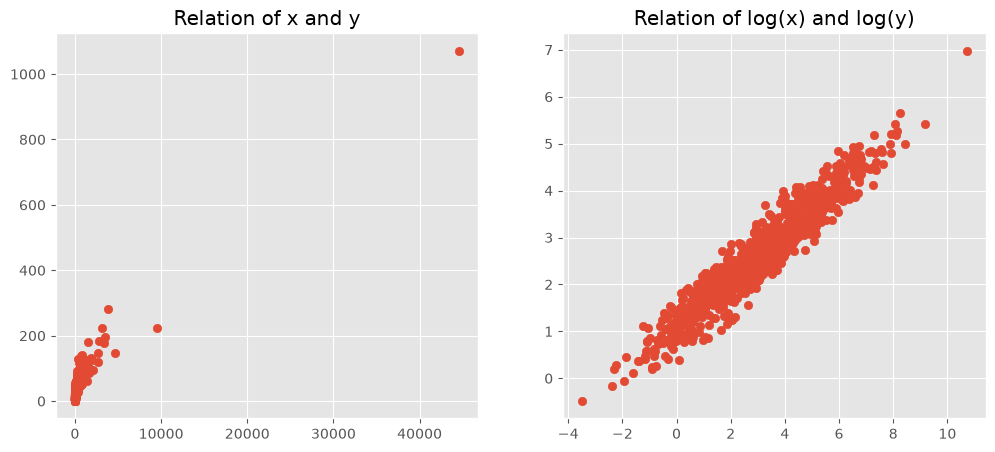

In [8]:
np.random.seed(42)
n = 1000
x = np.random.lognormal(mean = 3,sigma = 2, size = n)
e = np.random.normal(loc = 0, scale = 0.3, size = n)
y = 3 * x**0.5 * np.exp(e)

logx = np.log(x)
logy = np.log(y)

fig,ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))
ax[0].scatter(x, y)
ax[0].set_title("Relation of x and y")

ax[1].scatter(logx, logy)
ax[1].set_title("Relation of log(x) and log(y)")
plt.show()


And a regression model for this transformed data looks like this: 

In [9]:
X = sm.add_constant(logx)
model = sm.OLS(logy, X)
result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                 1.044e+04
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:00:27   Log-Likelihood:                -211.10
No. Observations:                1000   AIC:                             426.2
Df Residuals:                     998   BIC:                             436.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1386      0.017     65.183      0.0

Since we transformed both the predictor and the response variable, we can directly use the coefficients for making inferences. For instance:

"A 1% increase in $x$ is associated with approximately a 0.49% increase in $y$."

Note that the model recovered the exponent we used while generating the dataset, since $y = 3x^{0.5}e^{\varepsilon}$ becomes $\ln y = \ln 3 + 0.5\ln x + \varepsilon$ after taking logarithms. This is the reason a log-log model is so convenient: a power relationship turns into a linear one, and the slope is directly the exponent.


In the next example, we will transform $x$ only.


**Example 5**


$n = 1000$


$x \sim \text{lognormal}(3,\ 2^2)$


$\varepsilon \sim \mathcal{N}(0,\ 1)$


$y = 5 + 2\ln(x) + \varepsilon$


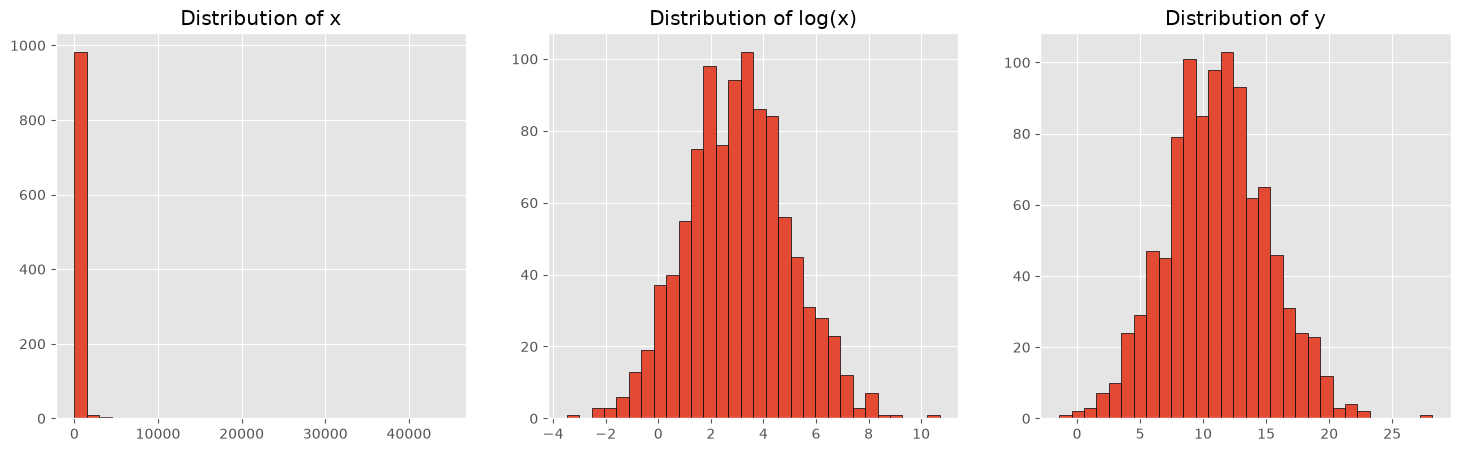

In [10]:
np.random.seed(42)
n = 1000
x = np.random.lognormal(mean = 3,sigma = 2, size = n)
e = np.random.normal(loc = 0, scale = 1, size = n)
y = 5 + 2 * np.log(x) + e

logx = np.log(x)

fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (18, 5))
ax[0].hist(x, bins = 30, edgecolor = "black")
ax[0].set_title("Distribution of x")

ax[1].hist(logx, bins = 30, edgecolor = "black")
ax[1].set_title("Distribution of log(x)")

ax[2].hist(y, bins = 30, edgecolor = "black")
ax[2].set_title("Distribution of y")

plt.show()


If we try to model the relationship between $x$ and $y$ directly, the model would be insufficient since the relationship is not linear on the raw scale. On top of that, the few very large values of $x$ would dominate the fit. But with the help of log transform, we can fit the following regression equation:

$y = b_0 + b_1\cdot\text{ln}(x)$


In [11]:
result_raw = sm.OLS(y, sm.add_constant(x)).fit()
print(f"R-squared with raw x: {result_raw.rsquared:.4f}")
print()

X = sm.add_constant(logx)
model = sm.OLS(y, X)
result = model.fit()

print(result.summary())


R-squared with raw x: 0.0793

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.510e+04
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:00:28   Log-Likelihood:                -1415.1
No. Observations:                1000   AIC:                             2834.
Df Residuals:                     998   BIC:                             2844.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1334 

The log transform lifted the $R^2$ score from 0.08 to 0.94, which shows how much of the relationship was hidden by the raw scale.

In this case, the interpretation is a bit trickier. Let's represent the change in x in the equation.

$y_1 - y_0 = b_1\cdot\text{ln}(\frac {x_1}{x_0}) +b_0 - b_0$

If we put the coefficients in the equation,

$\Delta y = 1.98\cdot\text{ln}(\frac {x_1}{x_0})$


If $x$ doubles, for instance,

$\Delta y \approx 1.98\times 0.693 = 1.372$

$y$ increases by approximately $1.372$ units.


## Interaction


What if the predictors $x_1$ and $x_2$ have a combined impact on $y$? In such scenarios, especially if the effects of both $x_1$ and $x_2$ are high, we can consider adding an interaction variable.


Interaction variables we introduce are directly derived from the existing predictors, so there is a high risk of multicollinearity. Therefore, we use centered versions of the predictors when creating interaction variables.


An interaction variable $x_1x_2$ is nothing but the multiplication of $x_1$ and $x_2$.


$x_1x_2 = x_1 \times x_2$


**Example 6**


$n = 1000$


$x_1 \sim \mathcal{N}(3, 1)$


$x_2 \sim \mathcal{N}(5, 1)$


$\varepsilon \sim \mathcal{N}(0, 1)$


$y = 5 + 2x_1 + 3x_2 + \varepsilon$


In [12]:
np.random.seed(42)
n = 1000
x1 = np.random.normal(loc = 3, scale = 1, size = n)
x2 = np.random.normal(loc = 5, scale = 1, size = n)
e = np.random.normal(loc = 0, scale = 1, size = n)
y = 5 + 2 * x1 + 3 * x2 + e

dataset = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
model = smf.ols('y ~ x1 + x2', data = dataset)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     6362.
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:00:28   Log-Likelihood:                -1401.5
No. Observations:                1000   AIC:                             2809.
Df Residuals:                     997   BIC:                             2824.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.9916      0.191     26.117      0.0

We will add $x_1x_2$ to the model as an interaction variable. Note that we center the main effects as well, otherwise the interaction term stays correlated with them and the main effect coefficients keep referring to a point where the other predictor is zero.

$x_1x_2 = x_{1,centered} \times x_{2,centered} $


In [13]:
x1_centered = x1 - np.mean(x1)
x2_centered = x2 - np.mean(x2)

dataset_interaction = pd.DataFrame({'x1': x1_centered, 'x2': x2_centered, 'x1_x2': x1_centered * x2_centered, 'y': y})
model_interaction = smf.ols('y ~ x1 + x2 + x1_x2', data = dataset_interaction)
result_interaction = model_interaction.fit()
print(result_interaction.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     4242.
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:00:28   Log-Likelihood:                -1401.0
No. Observations:                1000   AIC:                             2810.
Df Residuals:                     996   BIC:                             2830.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     26.2583      0.031    843.023      0.0

There is no improvement in AIC or $R^2$ score. Also $p > 0.05$ for the interaction variable. Hence we can conclude that adding an interaction variable in this case did not yield better results. 

The techniques in this notebook give us a small toolbox for reshaping predictors so they meet the model's assumptions and stay interpretable. Keep in mind that which transformation to use should always be guided by the data and the question at hand. There is no one size fits all solution.
